# 对LFW人脸数据，使用逻辑回归建模预测，和SVM对比差异
## 导入库

In [1]:
import numpy as np
import pandas as pd
from time import perf_counter
from datetime import datetime

from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

## 加载数据

In [2]:
# 加载人脸数据，labled faces wild
# 从 sklearn 数据集中加载 LFW 人脸数据（按原始尺寸，且每人至少 70 张）
data = datasets.fetch_lfw_people(resize=1, min_faces_per_person=70)

# 提取特征矩阵（每张人脸拉平成一维向量）
X = data['data']

# 提取标签（对应人物类别索引）
y = data['target']

# 提取原始人脸图像（三维数组：样本数 × 高 × 宽）
faces = data['images']

# 显示特征、图像和标签的形状
display(X.shape, faces.shape, y.shape)

# 提取人物名称列表（标签索引与姓名的映射）
target_names = data['target_names']

# 输出人物名称
target_names

(1288, 11750)

(1288, 125, 94)

(1288,)

array(['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
       'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair'], dtype='<U17')

## 建模

In [3]:
class Timer:
    """可复用计时器：支持手动 start/stop，也支持 with 上下文。"""
    def __init__(self, name="任务", verbose=True):
        self.name = name
        self.verbose = verbose
        self.start_time = None
        self.end_time = None
        self.duration = None

    def start(self):
        self.start_time = datetime.now()
        self.end_time = None
        self.duration = None
        return self

    def stop(self):
        if self.start_time is None:
            raise ValueError("计时器尚未启动，请先调用 start()")
        self.end_time = datetime.now()
        self.duration = self.end_time - self.start_time
        if self.verbose:
            print(f"[{self.name}] 耗时: {self.duration.total_seconds():.4f} 秒")
        return self.duration

    @property
    def seconds(self):
        if self.duration is None:
            return None
        return self.duration.total_seconds()

    def __enter__(self):
        return self.start()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.stop()


def timeit(name="函数", verbose=True):
    """函数装饰器版本计时器。"""
    def decorator(func):
        def wrapper(*args, **kwargs):
            timer = Timer(name=name or func.__name__, verbose=verbose).start()
            result = func(*args, **kwargs)
            timer.stop()
            return result
        return wrapper
    return decorator


# 用法示例1：with 代码块
# with Timer("SVC训练"):
#     svc.fit(X_train, y_tain)

# 用法示例2：手动计时
# t = Timer("网格搜索").start()
# grid.fit(X_train, y_tain)
# t.stop()

# 用法示例3：装饰器
# @timeit("预测")
# def run_predict(model, X):
#     return model.predict(X_test)

In [4]:
# 外层：评估泛化误差
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 内层：在外层训练折中做超参数搜索
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [6]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("clf", LogisticRegression(
        max_iter=5000,
    ))
])

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("clf", SVC(
        kernel="linear"
    ))
])

In [7]:
lr_param_grid = {
    "clf__C": np.logspace(-3, 2, 10),
    "clf__solver": ["lbfgs", "newton-cg", "saga"]
}

svm_param_grid = {
    "clf__C": np.logspace(-3, 2, 10),
    "clf__tol": [1e-2, 1e-3, 1e-4]
}

### 网络搜索最优参数

In [8]:
lr_search = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    scoring="accuracy",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

In [9]:
records = []

for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ----- LR -----
    t0 = perf_counter()
    lr_search.fit(X_train, y_train)
    lr_fit_time = perf_counter() - t0

    lr_best = lr_search.best_estimator_
    lr_pred = lr_best.predict(X_test)

    lr_acc = accuracy_score(y_test, lr_pred)
    lr_bacc = balanced_accuracy_score(y_test, lr_pred)
    lr_f1 = f1_score(y_test, lr_pred, average="macro")

    records.append({
        "fold": fold_id,
        "model": "LogisticRegression",
        "outer_acc": lr_acc,
        "outer_bal_acc": lr_bacc,
        "outer_macro_f1": lr_f1,
        "inner_best_score": lr_search.best_score_,
        "best_params": lr_search.best_params_,
        "fit_time_sec": lr_fit_time
    })

    # ----- Linear SVM -----
    t0 = perf_counter()
    svm_search.fit(X_train, y_train)
    svm_fit_time = perf_counter() - t0

    svm_best = svm_search.best_estimator_
    svm_pred = svm_best.predict(X_test)

    svm_acc = accuracy_score(y_test, svm_pred)
    svm_bacc = balanced_accuracy_score(y_test, svm_pred)
    svm_f1 = f1_score(y_test, svm_pred, average="macro")

    records.append({
        "fold": fold_id,
        "model": "LinearSVM",
        "outer_acc": svm_acc,
        "outer_bal_acc": svm_bacc,
        "outer_macro_f1": svm_f1,
        "inner_best_score": svm_search.best_score_,
        "best_params": svm_search.best_params_,
        "fit_time_sec": svm_fit_time
    })


/home/lanshi/Projects/Learning/Tutorials/AIoT_notebook/ML/Linear-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/home/lanshi/Projects/Learning/Tutorials/AIoT_notebook/ML/Linear-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/lanshi/Projects/Learning/Tutorials/AIoT_notebook/ML/Linear-classification/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
  

In [11]:
df = pd.DataFrame(records)

print("\n===== 每折结果 =====")
print(df[["fold", "model", "outer_acc", "outer_bal_acc", "outer_macro_f1", "inner_best_score", "fit_time_sec"]])

summary = (
    df.groupby("model")[["outer_acc", "outer_bal_acc", "outer_macro_f1", "fit_time_sec"]]
      .agg(["mean", "std"])
)

print("\n===== 汇总结果（mean ± std） =====")
print(summary)

print("\n===== 每折最佳参数 =====")
print(df[["fold", "model", "best_params"]])
df.to_csv("./records.csv")


===== 每折结果 =====
   fold               model  outer_acc  outer_bal_acc  outer_macro_f1  \
0     1  LogisticRegression   0.864341       0.824111        0.825004   
1     1           LinearSVM   0.852713       0.816914        0.819966   
2     2  LogisticRegression   0.813953       0.725138        0.739871   
3     2           LinearSVM   0.841085       0.783399        0.791985   
4     3  LogisticRegression   0.833333       0.767142        0.785849   
5     3           LinearSVM   0.829457       0.756655        0.780434   
6     4  LogisticRegression   0.832685       0.789384        0.792643   
7     4           LinearSVM   0.856031       0.840377        0.828622   
8     5  LogisticRegression   0.828794       0.775728        0.787454   
9     5           LinearSVM   0.828794       0.796102        0.801155   

   inner_best_score  fit_time_sec  
0          0.835922     61.789858  
1          0.837864     56.849956  
2          0.845631     59.061426  
3          0.825243     56.373050 

### 最优参数建模

In [17]:
# {'clf__C': np.float64(0.003593813663804626), 'clf__tol': 0.01}
with Timer("最优参数建模"):
    svc=Pipeline([
        ('scaler',StandardScaler()),
        ('PCA',PCA(n_components=0.95)),
        ('svc',SVC(C=0.003593813663804626,kernel='linear',tol=1e-2))
    ])
    svc.fit(X_train,y_train)
    display(svc.score(X_train,y_train))
    display(svc.score(X_test,y_test))

1.0

0.8287937743190662

[最优参数建模] 耗时: 2.2236 秒


## 可视化

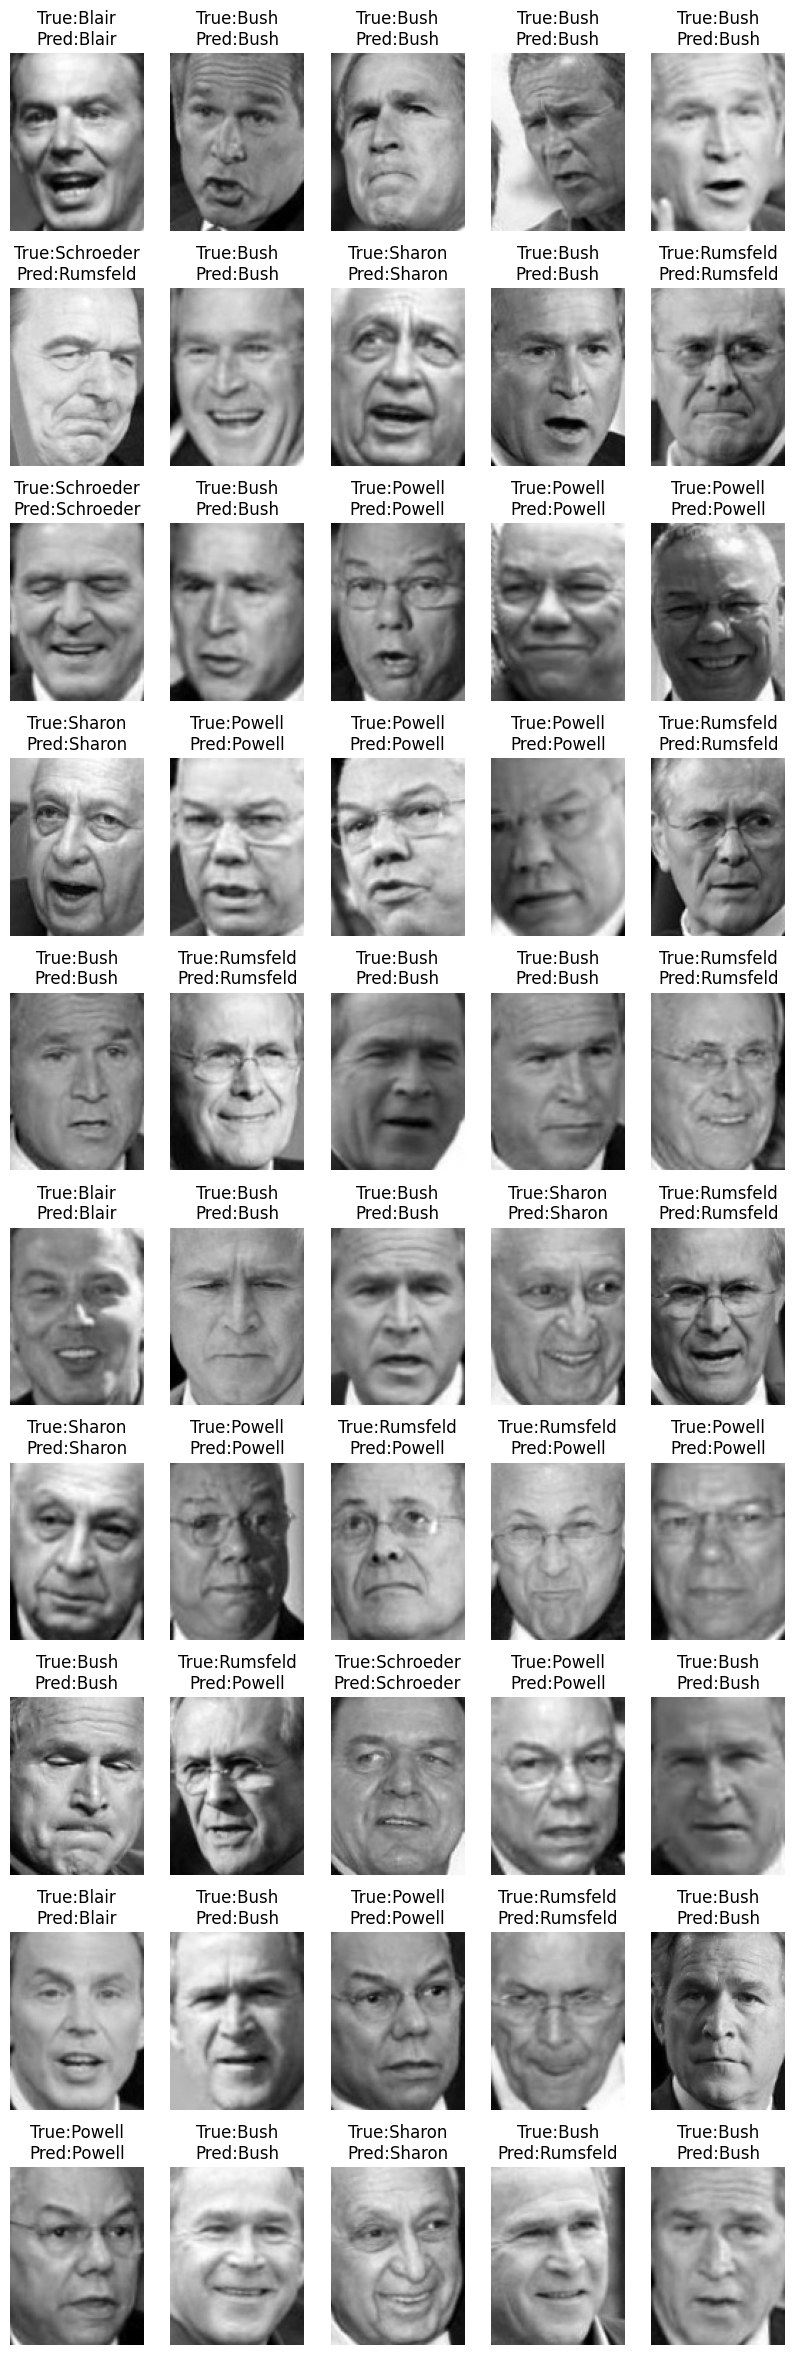

In [18]:
y_pred=svc.predict(X_test)
import matplotlib.pyplot as plt
faces_test = faces[test_idx]
plt.figure(figsize=(5 * 2, 10 * 3))
for i in range(50):
    plt.subplot(10,5,i+1)
    plt.imshow(faces_test[i],cmap="gray")
    plt.axis('off')
    true_name=target_names[y_test[i]].split(' ')[-1]
    predict_name=target_names[y_pred[i]].split(' ')[-1]
    plt.title('True:%s\nPred:%s' % (true_name,predict_name))